# 💸 Remittances Ate Pakistan's Economy (2000–2025)

> *How a nation quietly stopped exporting goods — and started exporting its people.*

In 2000, Pakistan's diaspora sent home **$1.08 billion** in remittances. Exports stood at **$9.2 billion** — nearly 9× larger.  
By 2025, remittances had grown to **$38 billion**, **surpassing exports ($34B)** for the first time in history.

This notebook unpacks what that structural transformation looks like — and what it means for Pakistan's economic future.

---
**Dataset:** Pakistan Economic Indicators 2000–2025  
**Key Variables:** Remittances, Exports, FDI, GDP, PKR/USD, IMF Programs  
**Notebook Sections:**
1. The Crossover: When Remittances Overtook Exports
2. Remittances vs. FDI — The Tradeoff
3. Remittances as a % of GDP: The Growing Dependence
4. The Foreign Exchange Lifeline
5. The Full Picture: A Multi-Panel Story

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'grid.linestyle':    '--',
    'figure.dpi':        150,
})

# ── Palette ──────────────────────────────────────────────────────────────────
GREEN  = '#2ECC71'   # remittances
BLUE   = '#2980B9'   # exports
ORANGE = '#E67E22'   # FDI
RED    = '#E74C3C'   # danger / deficit
DARK   = '#2C3E50'   # text / lines
LIGHT  = '#ECF0F1'   # backgrounds
GOLD   = '#F39C12'   # highlights

print('✅ Libraries loaded.')

✅ Libraries loaded.


In [2]:
# ── Load Data ────────────────────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/alitaqishah/pakistan-economic-indicators-2000-2025/pakistan_economic_indicators_2000_2025.csv')

# Derived columns
df['remit_export_ratio'] = df['remittances_usd_bn'] / df['exports_usd_bn']
df['forex_from_remit']   = df['remittances_usd_bn'] / (df['remittances_usd_bn'] + df['exports_usd_bn']) * 100
df['net_fdi_remit_gap']  = df['remittances_usd_bn'] - df['fdi_inflows_usd_bn']

print(df[['year','remittances_usd_bn','exports_usd_bn','fdi_inflows_usd_bn','remittances_gdp_pct']].to_string(index=False))

 year  remittances_usd_bn  exports_usd_bn  fdi_inflows_usd_bn  remittances_gdp_pct
 2000                1.08             9.2                0.31                 1.08
 2001                1.46             9.8                0.38                 1.44
 2002                2.39            10.0                0.82                 2.22
 2003                3.96            11.7                0.53                 3.40
 2004                3.87            14.0                1.12                 3.05
 2005                4.28            16.5                2.20                 3.11
 2006                5.12            18.6                4.27                 3.36
 2007                6.14            17.5                5.59                 3.65
 2008                6.45            20.4                5.44                 3.35
 2009                7.81            19.6                2.34                 4.50
 2010                8.91            19.3                2.02                 5.03
 201

## 1 · The Crossover: When Remittances Overtook Exports

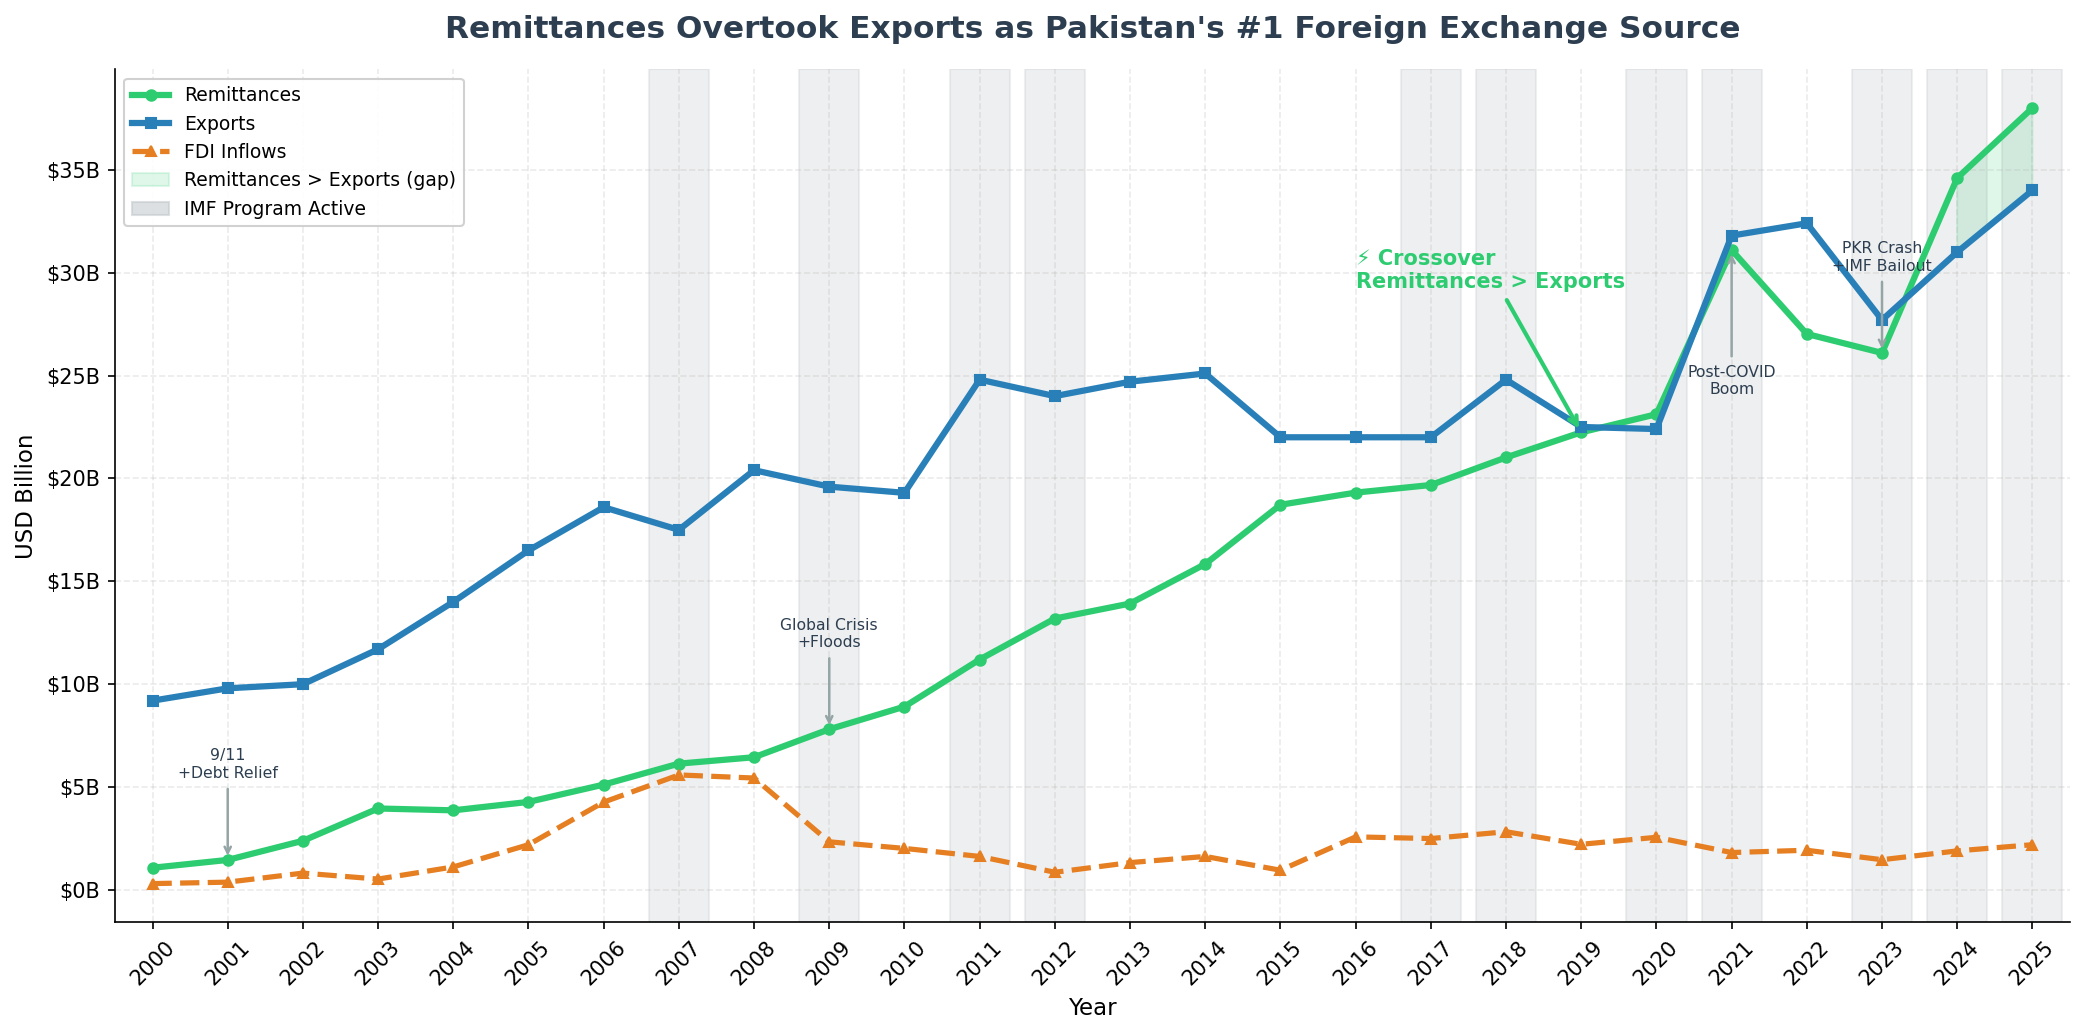


📌 Key stat: Remittances grew 35× from 2000–2025. Exports grew only 3.7×.


In [3]:
fig, ax = plt.subplots(figsize=(14, 7))

# Shade IMF program years
for _, row in df[df['imf_program_active'] == 1].iterrows():
    ax.axvspan(row['year'] - 0.4, row['year'] + 0.4, color='#BDC3C7', alpha=0.25, zorder=0)

# Main lines
ax.plot(df['year'], df['remittances_usd_bn'], color=GREEN,  lw=3,   marker='o', ms=5, label='Remittances')
ax.plot(df['year'], df['exports_usd_bn'],     color=BLUE,   lw=3,   marker='s', ms=5, label='Exports')
ax.plot(df['year'], df['fdi_inflows_usd_bn'], color=ORANGE, lw=2.5, marker='^', ms=5, label='FDI Inflows', linestyle='--')

# Fill gap between remittances and exports after crossover
crossover_mask = df['remittances_usd_bn'] >= df['exports_usd_bn']
ax.fill_between(df['year'], df['remittances_usd_bn'], df['exports_usd_bn'],
                where=crossover_mask, alpha=0.15, color=GREEN, label='Remittances > Exports (gap)')

# Annotate the crossover
cross_year = df.loc[(df['remit_export_ratio'] - 1).abs().idxmin(), 'year']
cross_val  = df.loc[df['year'] == cross_year, 'remittances_usd_bn'].values[0]
ax.annotate('⚡ Crossover\nRemittances > Exports',
            xy=(cross_year, cross_val), xytext=(cross_year - 3, cross_val + 7),
            fontsize=10, fontweight='bold', color=GREEN,
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=2))

# Key events
events = {
    2001: ('9/11\n+Debt Relief', 'top'),
    2009: ('Global Crisis\n+Floods',   'top'),
    2021: ('Post-COVID\nBoom',         'bottom'),
    2023: ('PKR Crash\n+IMF Bailout',  'top'),
}
for yr, (label, pos) in events.items():
    val = df.loc[df['year'] == yr, 'remittances_usd_bn'].values[0]
    offset = 4 if pos == 'top' else -7
    ax.annotate(label, xy=(yr, val), xytext=(yr, val + offset),
                fontsize=7.5, color=DARK, ha='center',
                arrowprops=dict(arrowstyle='->', color='#95A5A6', lw=1.2))

# IMF legend patch
imf_patch = mpatches.Patch(color='#BDC3C7', alpha=0.5, label='IMF Program Active')

ax.set_title('Remittances Overtook Exports as Pakistan\'s #1 Foreign Exchange Source',
             fontsize=15, fontweight='bold', pad=15, color=DARK)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('USD Billion', fontsize=11)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax.set_xlim(1999.5, 2025.5)
ax.set_xticks(df['year'])
ax.tick_params(axis='x', rotation=45)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [imf_patch], labels + ['IMF Program Active'],
          loc='upper left', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig('plot1_crossover.png', bbox_inches='tight', dpi=150)
plt.show()
print('\n📌 Key stat: Remittances grew 35× from 2000–2025. Exports grew only 3.7×.')

## 2 · Remittances vs. FDI — The Devastating Tradeoff

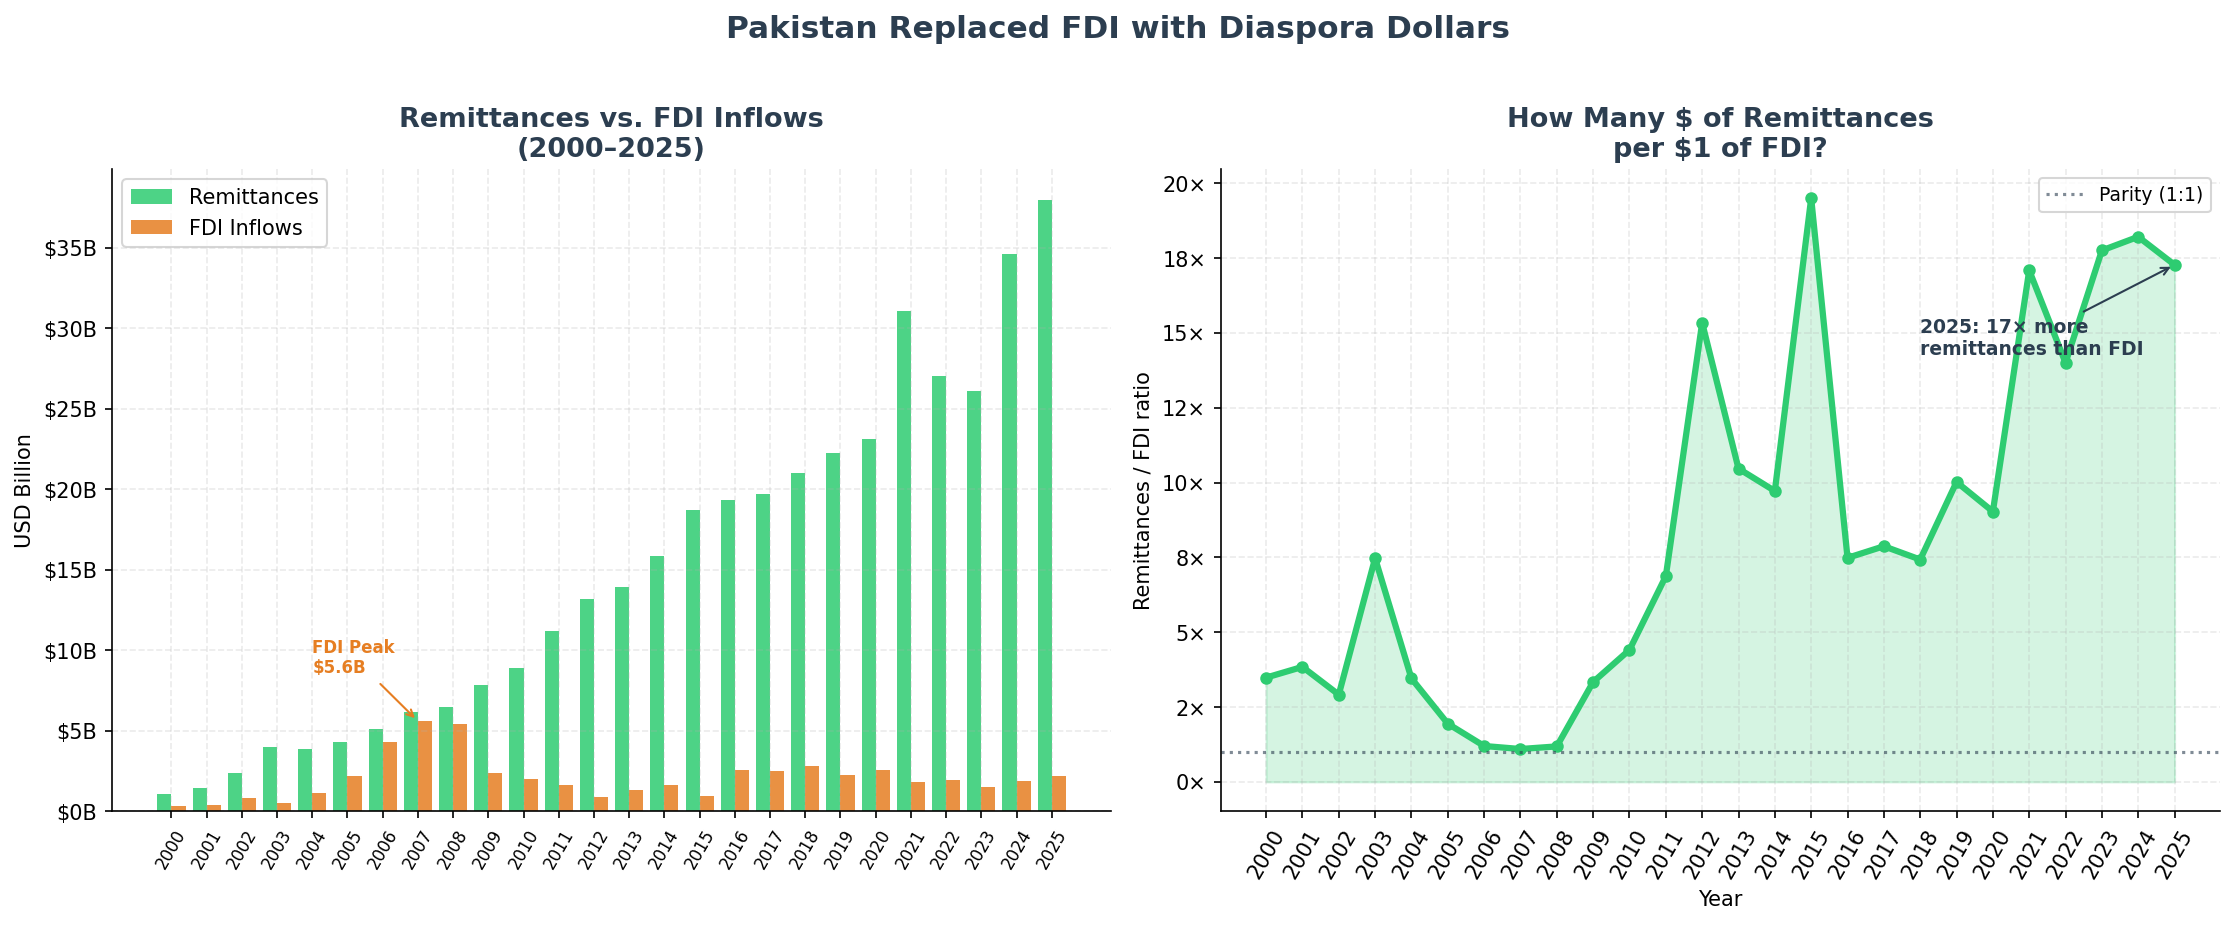


📌 In 2007 (CPEC hype peak), FDI hit $5.59B.
   By 2025, FDI = $2.20B — barely recovered.
   Meanwhile remittances = $38.0B — a 17× multiple of FDI.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: Bar chart comparison ────────────────────────────────────────────────
ax = axes[0]
x  = np.arange(len(df))
w  = 0.4

bars_r = ax.bar(x - w/2, df['remittances_usd_bn'], w, color=GREEN,  alpha=0.85, label='Remittances')
bars_f = ax.bar(x + w/2, df['fdi_inflows_usd_bn'], w, color=ORANGE, alpha=0.85, label='FDI Inflows')

ax.set_xticks(x)
ax.set_xticklabels(df['year'], rotation=60, fontsize=8)
ax.set_title('Remittances vs. FDI Inflows\n(2000–2025)', fontsize=13, fontweight='bold', color=DARK)
ax.set_ylabel('USD Billion')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax.legend(fontsize=10)

# Annotate the FDI peak and collapse
fdi_peak_idx = df['fdi_inflows_usd_bn'].idxmax()
ax.annotate(f"FDI Peak\n${df.loc[fdi_peak_idx,'fdi_inflows_usd_bn']:.1f}B",
            xy=(fdi_peak_idx, df.loc[fdi_peak_idx,'fdi_inflows_usd_bn']),
            xytext=(fdi_peak_idx - 3, df.loc[fdi_peak_idx,'fdi_inflows_usd_bn'] + 3),
            fontsize=8, color=ORANGE, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=ORANGE))

# ── Right: Ratio — Remittances per $1 of FDI ─────────────────────────────────
ax2  = axes[1]
ratio = df['remittances_usd_bn'] / df['fdi_inflows_usd_bn']

ax2.fill_between(df['year'], ratio, alpha=0.2, color=GREEN)
ax2.plot(df['year'], ratio, color=GREEN, lw=3, marker='o', ms=5)
ax2.axhline(1, color=DARK, linestyle=':', lw=1.5, alpha=0.6, label='Parity (1:1)')

ax2.set_title('How Many $ of Remittances\nper $1 of FDI?', fontsize=13, fontweight='bold', color=DARK)
ax2.set_xlabel('Year')
ax2.set_ylabel('Remittances / FDI ratio')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}×'))
ax2.set_xticks(df['year'])
ax2.tick_params(axis='x', rotation=60)
ax2.legend(fontsize=9)

# Annotate latest ratio
last = df.iloc[-1]
ax2.annotate(f"2025: {last['remittances_usd_bn']/last['fdi_inflows_usd_bn']:.0f}× more\nremittances than FDI",
             xy=(2025, ratio.iloc[-1]),
             xytext=(2018, ratio.iloc[-1] - 3),
             fontsize=9, color=DARK, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=DARK))

plt.suptitle('Pakistan Replaced FDI with Diaspora Dollars', fontsize=15, fontweight='bold', color=DARK, y=1.02)
plt.tight_layout()
plt.savefig('plot2_fdi_vs_remittances.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n📌 In 2007 (CPEC hype peak), FDI hit ${df['fdi_inflows_usd_bn'].max():.2f}B.")
print(f"   By 2025, FDI = ${df.loc[df['year']==2025,'fdi_inflows_usd_bn'].values[0]:.2f}B — barely recovered.")
print(f"   Meanwhile remittances = ${df.loc[df['year']==2025,'remittances_usd_bn'].values[0]:.1f}B — a {ratio.iloc[-1]:.0f}× multiple of FDI.")

## 3 · Remittances as % of GDP — The Growing Dependence

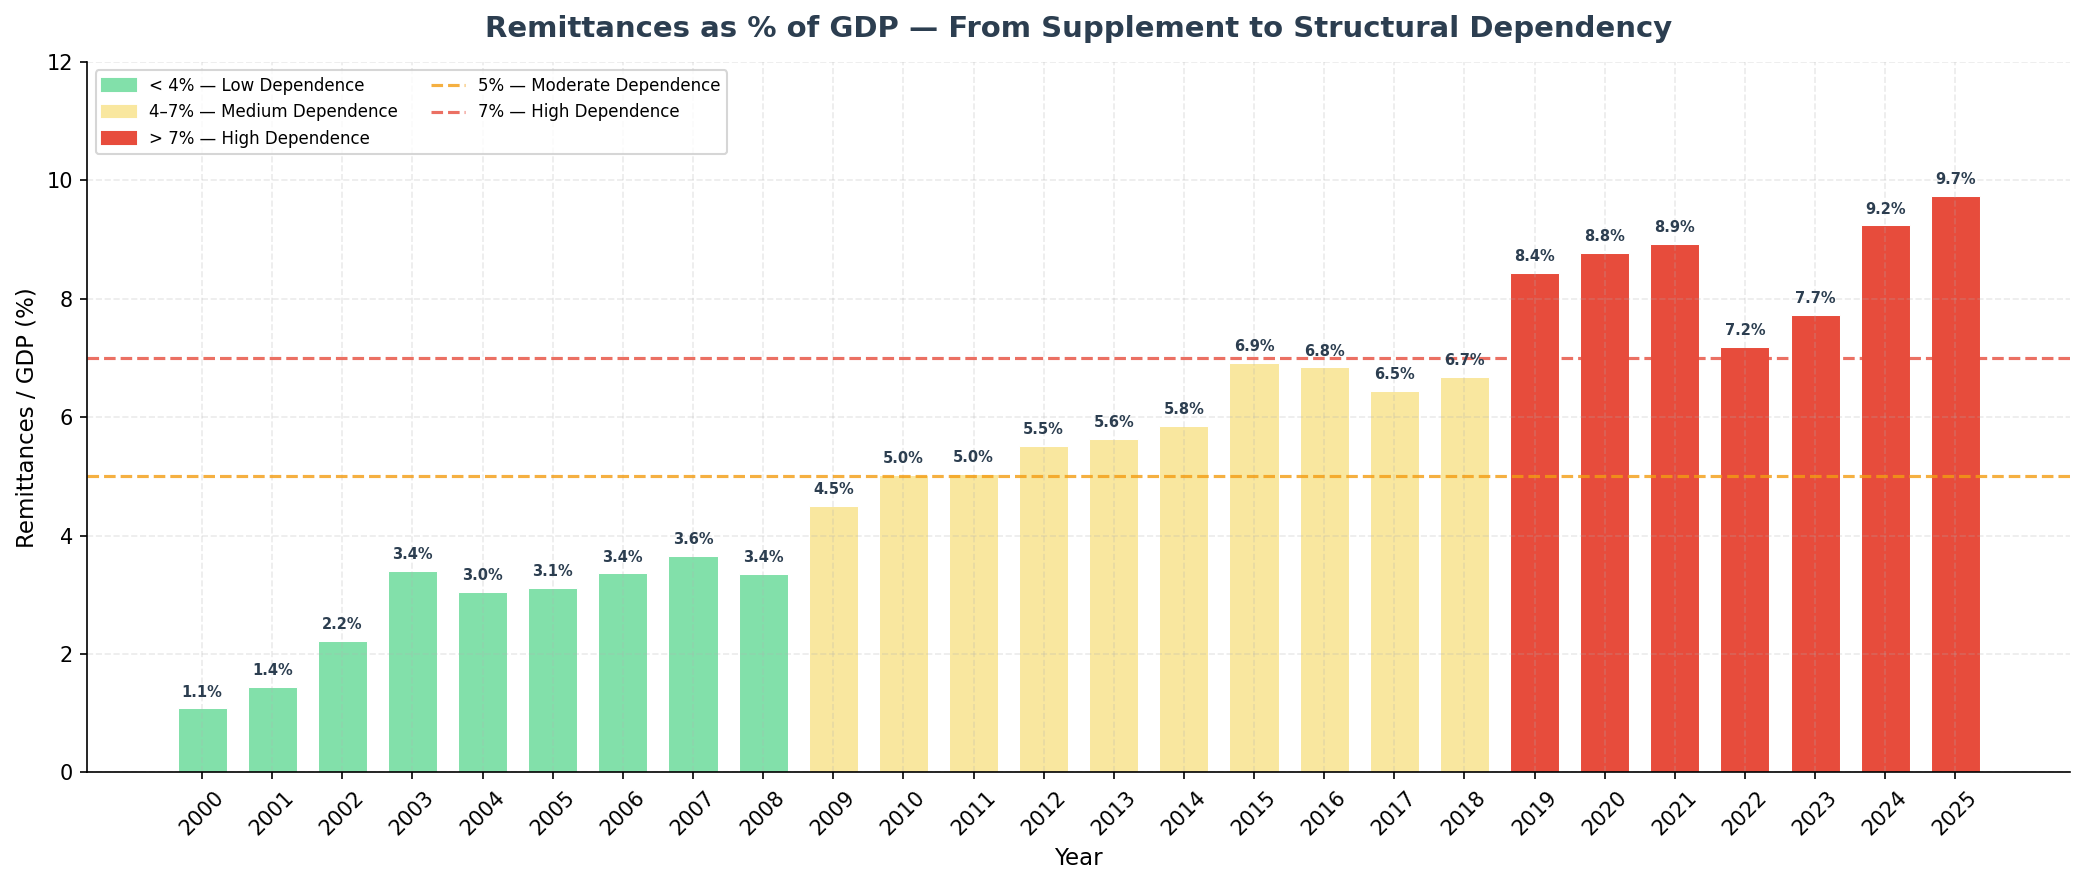


📌 Remittances/GDP: 1.08% in 2000 → 9.74% in 2025
   For context, the global average for remittance-dependent economies is ~5–7%.


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

# Colour bars by severity
colors = []
for pct in df['remittances_gdp_pct']:
    if pct < 4:   colors.append('#82E0AA')  # low dependence
    elif pct < 7: colors.append('#F9E79F')  # medium
    else:         colors.append('#E74C3C')  # high dependence

bars = ax.bar(df['year'], df['remittances_gdp_pct'], color=colors, edgecolor='white', linewidth=0.5, width=0.7)

# Reference lines
ax.axhline(y=5, color='#F39C12', linestyle='--', lw=1.5, alpha=0.8, label='5% — Moderate Dependence')
ax.axhline(y=7, color=RED,       linestyle='--', lw=1.5, alpha=0.8, label='7% — High Dependence')

# Value labels on top
for bar, val in zip(bars, df['remittances_gdp_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=7, color=DARK, fontweight='bold')

# Legend patches
patches = [
    mpatches.Patch(color='#82E0AA', label='< 4% — Low Dependence'),
    mpatches.Patch(color='#F9E79F', label='4–7% — Medium Dependence'),
    mpatches.Patch(color='#E74C3C', label='> 7% — High Dependence'),
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=patches + handles, labels=[p.get_label() for p in patches] + labels,
          fontsize=8, loc='upper left', ncol=2)

ax.set_title('Remittances as % of GDP — From Supplement to Structural Dependency',
             fontsize=14, fontweight='bold', color=DARK, pad=12)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Remittances / GDP (%)', fontsize=11)
ax.set_xticks(df['year'])
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 12)

plt.tight_layout()
plt.savefig('plot3_gdp_dependence.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n📌 Remittances/GDP: {df.loc[df['year']==2000,'remittances_gdp_pct'].values[0]:.2f}% in 2000 → {df.loc[df['year']==2025,'remittances_gdp_pct'].values[0]:.2f}% in 2025")
print("   For context, the global average for remittance-dependent economies is ~5–7%.")

## 4 · Remittances as the Foreign Exchange Lifeline

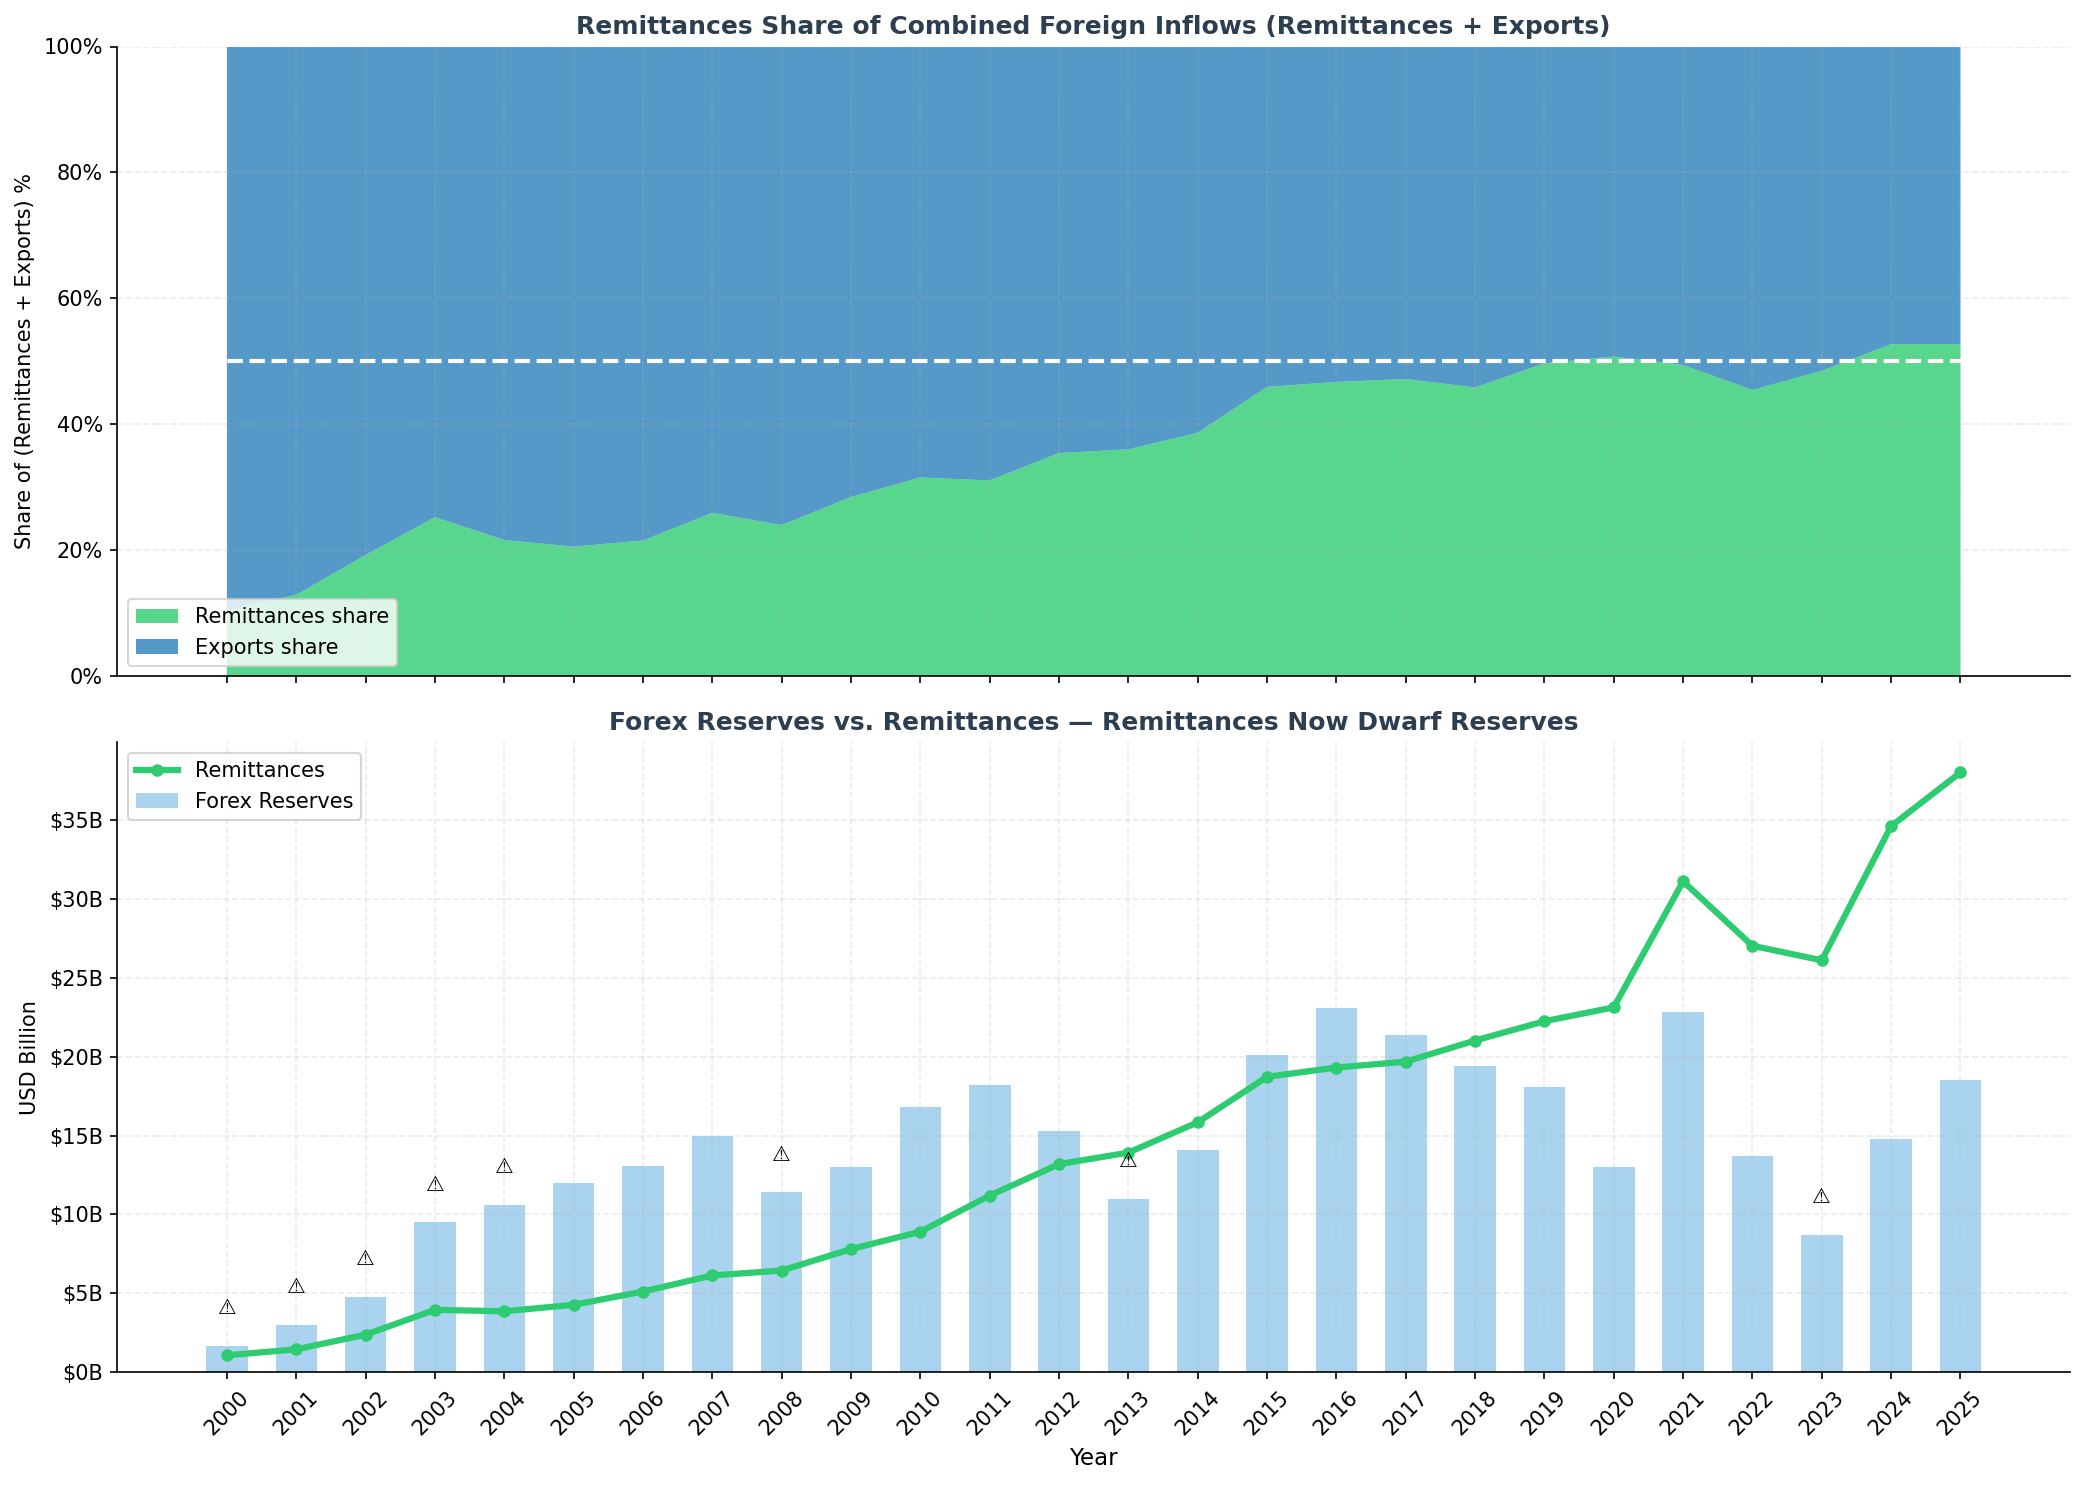

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ── Top: Stacked area — Remittances vs Exports share of inflows ──────────────
ax = axes[0]
total = df['remittances_usd_bn'] + df['exports_usd_bn']
remit_share  = df['remittances_usd_bn'] / total * 100
export_share = df['exports_usd_bn']     / total * 100

ax.stackplot(df['year'], remit_share, export_share,
             labels=['Remittances share', 'Exports share'],
             colors=[GREEN, BLUE], alpha=0.8)
ax.axhline(50, color='white', lw=2, linestyle='--')
ax.text(2025.3, 52, '50%', color='white', fontsize=9, fontweight='bold', va='center')

ax.set_ylabel('Share of (Remittances + Exports) %', fontsize=10)
ax.set_title('Remittances Share of Combined Foreign Inflows (Remittances + Exports)',
             fontsize=12, fontweight='bold', color=DARK)
ax.set_ylim(0, 100)
ax.legend(loc='lower left', fontsize=10)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

# ── Bottom: Forex reserves vs remittances ────────────────────────────────────
ax2 = axes[1]
ax2.bar(df['year'], df['forex_reserves_usd_bn'], color='#85C1E9', alpha=0.7, label='Forex Reserves', width=0.6)
ax2.plot(df['year'], df['remittances_usd_bn'],   color=GREEN,     lw=3,  marker='o', ms=5, label='Remittances')

# Annotate crisis years where reserves crashed
crisis_years = df[df['forex_reserves_usd_bn'] < 12]
for _, row in crisis_years.iterrows():
    ax2.annotate('⚠️', xy=(row['year'], row['forex_reserves_usd_bn']),
                 xytext=(row['year'], row['forex_reserves_usd_bn'] + 2),
                 fontsize=10, ha='center')

ax2.set_ylabel('USD Billion', fontsize=10)
ax2.set_title('Forex Reserves vs. Remittances — Remittances Now Dwarf Reserves',
              fontsize=12, fontweight='bold', color=DARK)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax2.set_xticks(df['year'])
ax2.tick_params(axis='x', rotation=45)
ax2.legend(fontsize=10)
ax2.set_xlabel('Year', fontsize=11)

plt.tight_layout()
plt.savefig('plot4_forex_lifeline.png', bbox_inches='tight', dpi=150)
plt.show()

## 5 · The Full Picture — A Multi-Panel Story Dashboard

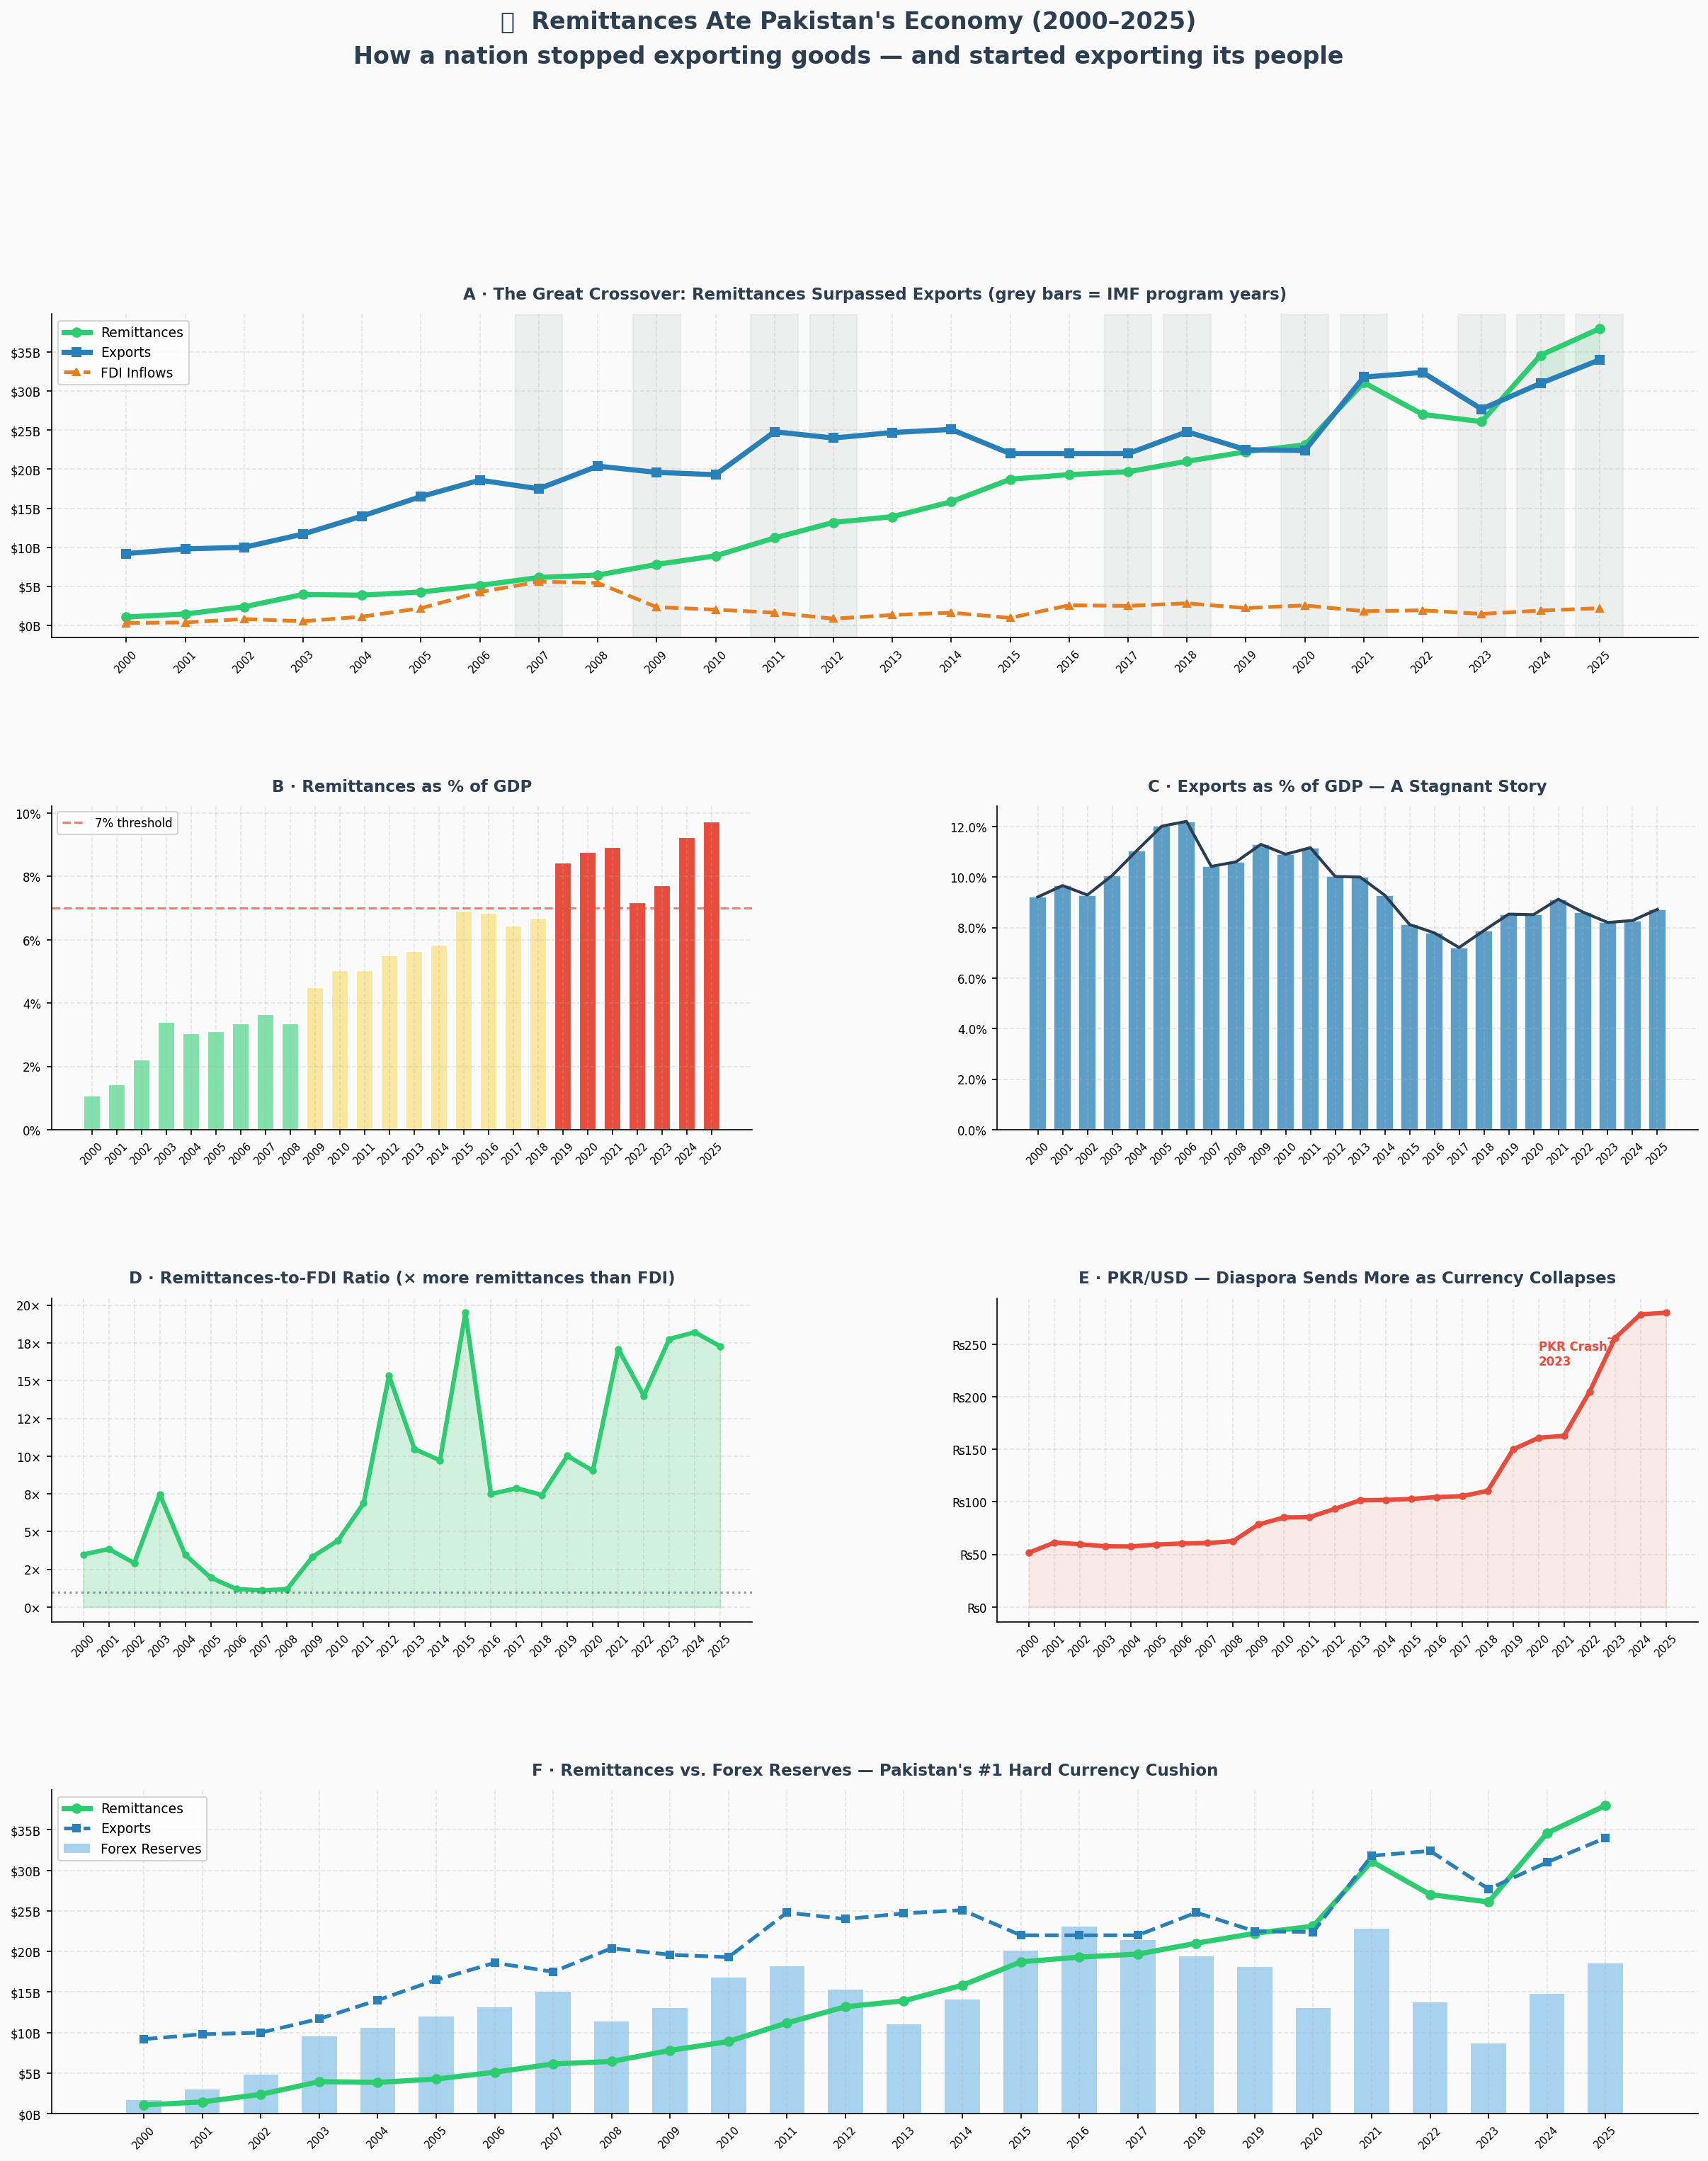

✅ Dashboard saved.


In [7]:
fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor('#FAFAFA')

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.52, wspace=0.35)

# ── Helper ───────────────────────────────────────────────────────────────────
def style_ax(ax, title):
    ax.set_title(title, fontsize=11, fontweight='bold', color=DARK, pad=10)
    ax.set_facecolor('#FAFAFA')
    for spine in ['top','right']:
        ax.spines[spine].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=8)

# ── Panel A: The Crossover ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
for _, row in df[df['imf_program_active'] == 1].iterrows():
    ax1.axvspan(row['year'] - 0.4, row['year'] + 0.4, color='#BDC3C7', alpha=0.2)
ax1.plot(df['year'], df['remittances_usd_bn'], color=GREEN,  lw=3.5, marker='o', ms=6, label='Remittances')
ax1.plot(df['year'], df['exports_usd_bn'],     color=BLUE,   lw=3.5, marker='s', ms=6, label='Exports')
ax1.plot(df['year'], df['fdi_inflows_usd_bn'], color=ORANGE, lw=2.5, marker='^', ms=5, label='FDI Inflows', linestyle='--')
ax1.fill_between(df['year'], df['remittances_usd_bn'], df['exports_usd_bn'],
                 where=df['remittances_usd_bn'] >= df['exports_usd_bn'], alpha=0.12, color=GREEN)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax1.set_xticks(df['year'])
ax1.legend(fontsize=9, loc='upper left')
style_ax(ax1, 'A · The Great Crossover: Remittances Surpassed Exports (grey bars = IMF program years)')

# ── Panel B: Remittances/GDP % ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
colors_b = ['#E74C3C' if v > 7 else '#F9E79F' if v > 4 else '#82E0AA' for v in df['remittances_gdp_pct']]
ax2.bar(df['year'], df['remittances_gdp_pct'], color=colors_b, width=0.7, edgecolor='white')
ax2.axhline(7, color=RED, linestyle='--', lw=1.5, alpha=0.7, label='7% threshold')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.set_xticks(df['year'])
ax2.legend(fontsize=8)
style_ax(ax2, 'B · Remittances as % of GDP')

# ── Panel C: Exports/GDP % ───────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.bar(df['year'], df['exports_gdp_pct'], color=BLUE, alpha=0.75, width=0.7, edgecolor='white')
ax3.plot(df['year'], df['exports_gdp_pct'], color=DARK, lw=2, linestyle='-')
ax3.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax3.set_xticks(df['year'])
style_ax(ax3, 'C · Exports as % of GDP — A Stagnant Story')

# ── Panel D: Remittances vs FDI ratio ───────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ratio = df['remittances_usd_bn'] / df['fdi_inflows_usd_bn']
ax4.fill_between(df['year'], ratio, alpha=0.2, color=GREEN)
ax4.plot(df['year'], ratio, color=GREEN, lw=3, marker='o', ms=4)
ax4.axhline(1, color=DARK, linestyle=':', lw=1.5, alpha=0.5)
ax4.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}×'))
ax4.set_xticks(df['year'])
style_ax(ax4, 'D · Remittances-to-FDI Ratio (× more remittances than FDI)')

# ── Panel E: PKR Depreciation ────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(df['year'], df['pkr_per_usd'], color=RED, lw=3, marker='o', ms=4)
ax5.fill_between(df['year'], df['pkr_per_usd'], alpha=0.1, color=RED)
ax5.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'₨{x:.0f}'))
ax5.set_xticks(df['year'])
ax5.annotate('PKR Crash\n2023', xy=(2023, 256), xytext=(2020, 230),
             fontsize=8, color=RED, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=RED))
style_ax(ax5, 'E · PKR/USD — Diaspora Sends More as Currency Collapses')

# ── Panel F: Remittances vs Forex Reserves ───────────────────────────────────
ax6 = fig.add_subplot(gs[3, :])
ax6.bar(df['year'], df['forex_reserves_usd_bn'],  color='#85C1E9', alpha=0.7, label='Forex Reserves', width=0.6)
ax6.plot(df['year'], df['remittances_usd_bn'],     color=GREEN,     lw=3.5, marker='o', ms=6, label='Remittances')
ax6.plot(df['year'], df['exports_usd_bn'],         color=BLUE,      lw=2.5, marker='s', ms=5, label='Exports', linestyle='--')
ax6.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:.0f}B'))
ax6.set_xticks(df['year'])
ax6.legend(fontsize=9, loc='upper left')
style_ax(ax6, 'F · Remittances vs. Forex Reserves — Pakistan\'s #1 Hard Currency Cushion')

# ── Super title ──────────────────────────────────────────────────────────────
fig.suptitle(
    '💸  Remittances Ate Pakistan\'s Economy (2000–2025)\n'
    'How a nation stopped exporting goods — and started exporting its people',
    fontsize=16, fontweight='bold', color=DARK, y=1.01, linespacing=1.6
)

plt.savefig('pakistan_remittances_dashboard.png', bbox_inches='tight', dpi=150, facecolor='#FAFAFA')
plt.show()
print('✅ Dashboard saved.')

## 6 · Key Takeaways

In [8]:
r2000 = df.loc[df['year']==2000, 'remittances_usd_bn'].values[0]
r2025 = df.loc[df['year']==2025, 'remittances_usd_bn'].values[0]
e2000 = df.loc[df['year']==2000, 'exports_usd_bn'].values[0]
e2025 = df.loc[df['year']==2025, 'exports_usd_bn'].values[0]
f2025 = df.loc[df['year']==2025, 'fdi_inflows_usd_bn'].values[0]
ratio_2025 = r2025 / f2025
gdp_dep_2025 = df.loc[df['year']==2025, 'remittances_gdp_pct'].values[0]
pkr_start = df.loc[df['year']==2000, 'pkr_per_usd'].values[0]
pkr_end   = df.loc[df['year']==2025, 'pkr_per_usd'].values[0]

print("=" * 60)
print("   REMITTANCES ATE PAKISTAN'S ECONOMY — KEY STATS")
print("=" * 60)
print(f"  Remittances growth : ${r2000:.2f}B → ${r2025:.0f}B  ({r2025/r2000:.0f}× increase)")
print(f"  Exports growth     : ${e2000:.1f}B  → ${e2025:.0f}B   ({e2025/e2000:.1f}× increase)")
print(f"  Remittances > FDI  : {ratio_2025:.0f}× more remittances than FDI in 2025")
print(f"  GDP dependence     : {gdp_dep_2025:.2f}% of GDP in 2025 (was 1.08% in 2000)")
print(f"  PKR collapse       : ₨{pkr_start} → ₨{pkr_end} per USD ({(pkr_end/pkr_start - 1)*100:.0f}% devaluation)")
print()
print("  ⚠️  IMPLICATION: As PKR weakens, diaspora remittances become")
print("     worth more in PKR terms — creating a perverse incentive")
print("     loop where currency collapse INCREASES remittance flow.")
print()
print("  📉  EXPORTS: Despite decades of policy push, exports as % of")
print("     GDP DECLINED from 9.2% (2000) to 8.7% (2025). Pakistan")
print("     exports more of its people than its products.")
print("=" * 60)

   REMITTANCES ATE PAKISTAN'S ECONOMY — KEY STATS
  Remittances growth : $1.08B → $38B  (35× increase)
  Exports growth     : $9.2B  → $34B   (3.7× increase)
  Remittances > FDI  : 17× more remittances than FDI in 2025
  GDP dependence     : 9.74% of GDP in 2025 (was 1.08% in 2000)
  PKR collapse       : ₨51.8 → ₨280.0 per USD (441% devaluation)

  ⚠️  IMPLICATION: As PKR weakens, diaspora remittances become
     worth more in PKR terms — creating a perverse incentive
     loop where currency collapse INCREASES remittance flow.

  📉  EXPORTS: Despite decades of policy push, exports as % of
     GDP DECLINED from 9.2% (2000) to 8.7% (2025). Pakistan
     exports more of its people than its products.
